# When Labels Lie
## Modul 03 — PeDaS 2026

Pada modul sebelumnya kita membangun model yang generalize. Sekarang kita membahas salah satu penyebab model sulit belajar: **label yang tidak selalu benar**.

Label dapat bermasalah karena salah ketik, definisi kategori yang tidak jelas, perbedaan penilaian antar-anotator, perubahan isi situs, atau kesalahan pada proses penggabungan data.

Tujuan modul ini bukan menghapus label yang terlihat aneh secara otomatis. Tujuannya adalah membuat proses yang membantu manusia menentukan data mana yang perlu diperiksa lebih dahulu.

Modul dibagi menjadi beberapa chapter:

1. membaca dan merapikan label;
2. mencari duplikat dan konflik;
3. memahami model disagreement;
4. membuat prediksi out-of-fold;
5. menyusun daftar prioritas pemeriksaan;
6. melihat dampak label noise;
7. memperbaiki label dengan prosedur yang aman;
8. membahas tahap lanjutan dan pitfall.

Metrik evaluasi tetap **Macro-F1**, sama seperti modul sebelumnya.

## Chapter 1 — Persiapan

Seluruh contoh menggunakan data imitasi IDADX yang sama. Tidak ada data tambahan dari luar.

In [1]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import f1_score, confusion_matrix
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_predict
)
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC

RANDOM_STATE = 2026

## Chapter 2 — Membaca data

Letakkan file CSV di dalam folder `data` yang berada pada direktori yang sama dengan notebook.

In [2]:
IDADX_NAME = "data/WSdata-idadx.phishes_10000_masked.csv"
idadx_raw = pd.read_csv(IDADX_NAME)
print(f"IDADX: {idadx_raw.shape[0]:,} baris × {idadx_raw.shape[1]} kolom")

IDADX: 10,000 baris × 14 kolom


In [3]:
idadx_raw[["url", "category"]].head()

,url,category
0,https://***********************.go.id.test/acc...,online gambling
1,http://*********.desa.id.test/promo/item-08250,online gambling
2,https://*********.go.id.test/access/item-00175,online gambling
3,https://******.id.test/service/item-06065,phishing
4,https://*********.desa.id.test/member/item-00295,online gambling


Sebelum mencari label yang salah, bedakan dua jenis masalah:

1. **masalah format**, misalnya `Phishing`, ` phishing`, dan `phishing`;
2. **masalah makna**, misalnya sebuah laporan diberi label `phishing` padahal isi sebenarnya adalah `fakeshop`.

Masalah format dapat diperbaiki dengan aturan sederhana. Masalah makna membutuhkan bukti dan pemeriksaan manusia.

In [4]:
raw_label_count = idadx_raw["category"].nunique()

idadx = idadx_raw.copy()
idadx["category"] = (
    idadx["category"]
    .str.strip()
    .str.lower()
)

clean_label_count = idadx["category"].nunique()

print(f"Variasi label sebelum dirapikan : {raw_label_count}")
print(f"Kategori setelah dirapikan      : {clean_label_count}")

Variasi label sebelum dirapikan : 26
Kategori setelah dirapikan      : 9


In [5]:
idadx["category"].value_counts()

category
online gambling    4996
phishing           3079
other               666
spam                445
malware             358
brand               209
fakeshop            151
violence             74
piiexposure          22
Name: count, dtype: int64

Normalisasi di atas hanya memperbaiki penulisan. Kode tersebut tidak menentukan apakah makna sebuah label sudah benar.

## Chapter 3 — Duplikat dan konflik label

Mulailah pemeriksaan dari aturan yang mudah dijelaskan.

- **Duplikat penuh:** semua nilai pada dua baris sama.
- **Konflik label:** URL yang sama muncul dengan lebih dari satu kategori.

Konflik tidak otomatis berarti salah label. Isi URL dapat berubah dari waktu ke waktu atau satu halaman dapat memiliki lebih dari satu bentuk penyalahgunaan.

In [6]:
full_duplicates = idadx.duplicated().sum()

label_per_url = idadx.groupby("url")["category"].nunique()
conflicting_urls = label_per_url[label_per_url > 1].index

print(f"Duplikat penuh                    : {full_duplicates:,}")
print(f"URL dengan lebih dari satu label  : {len(conflicting_urls):,}")

Duplikat penuh                    : 100
URL dengan lebih dari satu label  : 422


In [7]:
conflict_example = (
    idadx[idadx["url"].isin(conflicting_urls)]
    .sort_values(["url", "discovered"])
    [["url", "discovered", "category", "brand", "registrar"]]
)

conflict_example.head(15)

,url,discovered,category,brand,registrar
7898,http://****************************.biz.id.tes...,2025-10-18 09:16:11,phishing,-,Registrar Simulasi 17
7315,http://****************************.biz.id.tes...,2026-06-15 07:07:41,other,NaN,Registrar Simulasi 17
8814,http://****************************.id.test/do...,2023-11-28 17:50:01,online gambling,NaN,Registrar Simulasi 21
9,http://****************************.id.test/do...,2025-05-07 02:12:55,phishing,AkunNusa Simulasi,Registrar Simulasi 21
6689,http://***************************.go.id.test/...,2025-05-23 04:18:41,online gambling,AkunNusa Simulasi,Registrar Simulasi 11
3000,http://***************************.go.id.test/...,2025-08-11 05:31:40,phishing,BankPelangi Simulasi,Registrar Simulasi 11
3773,http://***************************.go.id.test/...,2024-01-01 17:59:13,online gambling,-,Registrar Simulasi 12
6399,http://***************************.go.id.test/...,2026-05-17 18:11:06,phishing,DompetAwan Simulasi,Registrar Simulasi 12
6369,http://***************************.go.id.test/...,2024-12-30 08:17:08,online gambling,NaN,Registrar Simulasi 11
1202,http://***************************.go.id.test/...,2025-06-22 05:04:06,other,-,Registrar Simulasi 11


Pada data imitasi, bagian domain dan URL sudah dimasking. Beberapa URL yang terlihat sama dapat berasal dari data asli yang berbeda. Karena itu, konflik pada kolom URL imitasi adalah **sinyal untuk diperiksa**, bukan bukti bahwa label salah.

Duplikat penuh dihapus sebelum pemodelan agar baris identik tidak dihitung berulang kali.

In [8]:
idadx = idadx.drop_duplicates().reset_index(drop=True)
idadx["row_id"] = idadx.index

print(f"Jumlah baris setelah menghapus duplikat penuh: {len(idadx):,}")

Jumlah baris setelah menghapus duplikat penuh: 9,900


## Chapter 4 — Menyiapkan teks dan model

Seperti modul sebelumnya, fitur dibuat dari `url`, `brand`, `sld`, dan `registrar`. Nomor item buatan pada URL imitasi dihapus.

Kolom hasil penanganan tidak dimasukkan karena dapat menyebabkan data leakage.

In [9]:
def clean_url(url):
    url = str(url)
    return re.sub(r"item-\d+", "", url, flags=re.IGNORECASE)


idadx["text"] = (
    "url " + idadx["url"].fillna("").map(clean_url)
    + " brand " + idadx["brand"].fillna("")
    + " sld " + idadx["sld"].fillna("")
    + " registrar " + idadx["registrar"].fillna("")
)

X = idadx["text"]
y = idadx["category"]

In [10]:
svm_pipeline = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            analyzer="char",
            ngram_range=(3, 5),
            min_df=2,
            max_features=10_000
        )
    ),
    (
        "svm",
        LinearSVC(
            C=1,
            class_weight="balanced",
            random_state=RANDOM_STATE
        )
    )
])

## Chapter 5 — Model disagreement

Salah satu cara mencari label yang patut diperiksa adalah membandingkan:

- label yang terdapat pada data;
- prediksi model.

Jika keduanya berbeda, terjadi **model disagreement**.

Namun disagreement memiliki setidaknya tiga kemungkinan:

1. label data salah;
2. model salah;
3. contoh memang ambigu.

Karena itu, prediksi model tidak boleh langsung menggantikan label.

### Mengapa harus out-of-fold?

Jangan melatih model pada seluruh data lalu memintanya menilai label pada data yang sama. Model sudah pernah melihat contoh tersebut dan hasilnya terlalu optimistis.

Gunakan prediksi **out-of-fold**:

1. data dibagi menjadi tiga fold;
2. dua fold digunakan untuk training;
3. fold yang tersisa diprediksi oleh model yang belum pernah melihatnya;
4. proses diulang sampai setiap baris memiliki satu prediksi.

TF-IDF berada di dalam pipeline sehingga vocabulary juga hanya dipelajari dari training fold.

In [11]:
cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=RANDOM_STATE
)

oof_prediction = cross_val_predict(
    svm_pipeline,
    X,
    y,
    cv=cv,
    method="predict",
    n_jobs=1
)

oof_score = f1_score(
    y,
    oof_prediction,
    average="macro",
    zero_division=0
)

print(f"Macro-F1 out-of-fold: {oof_score:.4f}")

Macro-F1 out-of-fold: 0.1236


Macro-F1 tetap digunakan karena kategori pada data tidak seimbang. Skor out-of-fold yang rendah memberi peringatan bahwa model belum cukup kuat untuk menjadi pemeriksa label secara otomatis.

In [12]:
comparison = pd.crosstab(
    y,
    oof_prediction,
    rownames=["Label data"],
    colnames=["Prediksi model"]
)

comparison

Prediksi model,brand,fakeshop,malware,online gambling,other,phishing,piiexposure,spam,violence
Label data,,,,,,,,,
brand,9,6,0,92,1,67,17,0,15
fakeshop,1,2,0,62,0,46,18,2,18
malware,7,4,0,165,1,112,45,0,19
online gambling,81,60,17,2347,21,1461,504,23,430
other,16,8,0,278,1,212,83,0,61
phishing,45,41,10,748,12,1672,285,15,225
piiexposure,0,0,0,10,0,8,2,1,0
spam,5,7,1,209,1,129,49,3,37
violence,1,2,0,34,1,22,8,1,4


Tabel di atas membantu melihat pola disagreement. Misalnya, jika banyak kategori berbeda selalu diprediksi sebagai satu kategori tertentu, masalahnya mungkin berada pada model atau fitur, bukan pada ribuan label sekaligus.

## Chapter 6 — Menentukan prioritas pemeriksaan

Selain menghasilkan kelas prediksi, Linear SVM menghasilkan **decision score**. Semakin besar jarak antara skor tertinggi dan skor kedua, semakin tegas pilihan model.

Kita memakai jarak tersebut sebagai nilai prioritas:

$$
	ext{margin}=	ext{skor tertinggi}-	ext{skor tertinggi kedua}
$$

Baris dengan label berbeda dari prediksi dan margin besar ditempatkan di bagian atas daftar pemeriksaan.

Margin bukan probabilitas dan bukan persentase keyakinan. Nilainya hanya digunakan untuk mengurutkan kasus.

In [13]:
oof_decision = cross_val_predict(
    svm_pipeline,
    X,
    y,
    cv=cv,
    method="decision_function",
    n_jobs=1
)

sorted_score = np.sort(oof_decision, axis=1)
margin = sorted_score[:, -1] - sorted_score[:, -2]

In [14]:
review_candidates = idadx[
    ["row_id", "url", "discovered", "category", "brand", "registrar"]
].copy()

review_candidates["model_prediction"] = oof_prediction
review_candidates["margin"] = margin
review_candidates["disagreement"] = (
    review_candidates["category"]
    != review_candidates["model_prediction"]
)

review_candidates = (
    review_candidates[review_candidates["disagreement"]]
    .sort_values("margin", ascending=False)
)

print(f"Jumlah disagreement: {len(review_candidates):,}")
review_candidates.head(20)

Jumlah disagreement: 5,860


,row_id,url,discovered,category,brand,registrar,model_prediction,margin,disagreement
4727,4727,http://****************.mil.id.test/service/it...,2024-02-17 15:20:26,online gambling,AkunNusa Simulasi,Registrar Simulasi 10,piiexposure,1.518608,True
4379,4379,https://**************.mil.id.test/archive/ite...,2025-07-14 01:04:41,online gambling,-,Registrar Simulasi 04,piiexposure,1.455492,True
5022,5022,https://**************.mil.id.test/service/ite...,2024-12-21 00:03:29,phishing,AkunNusa Simulasi,Registrar Simulasi 04,piiexposure,1.400525,True
7207,7207,http://************************.biz.id.test/do...,2025-09-19 04:24:14,spam,-,Registrar Simulasi 04,piiexposure,1.318830,True
718,718,https://***************.or.id.test/service/ite...,2025-04-16 10:38:07,online gambling,-,Registrar Simulasi 22,piiexposure,1.243212,True
9653,9653,http://*******************.or.id.test/document...,2025-11-03 09:16:54,phishing,PesanKita Simulasi,Registrar Simulasi 14,piiexposure,1.237622,True
5497,5497,http://**********************.co.id.test/docum...,2025-12-22 21:57:21,phishing,BankPelangi Simulasi,Registrar Simulasi 01,piiexposure,1.232355,True
1003,1003,http://**********.web.id.test/documents/item-0...,2026-03-29 20:43:48,online gambling,AkunNusa Simulasi,Registrar Simulasi 20,piiexposure,1.231564,True
683,683,http://****************************.id.test/se...,2026-02-28 20:44:54,online gambling,AkunNusa Simulasi,Registrar Simulasi 04,piiexposure,1.211323,True
5377,5377,http://*************.id.test/documents/item-00347,2024-02-25 06:31:03,online gambling,BankPelangi Simulasi,Registrar Simulasi 13,piiexposure,1.206068,True


Daftar di atas belum dapat disebut daftar *salah label*. Nama yang tepat adalah **kandidat pemeriksaan**.

Jika model memiliki Macro-F1 yang rendah, disagreement akan sangat banyak. Pada kondisi tersebut, ambil daftar teratas dalam jumlah yang sanggup diperiksa manusia, misalnya 50 atau 100 kasus. Jangan mengubah seluruh label berdasarkan model yang masih lemah.

In [15]:
top_review = review_candidates.head(100).copy()

top_review["review_status"] = "belum diperiksa"
top_review["reviewed_label"] = ""
top_review["review_note"] = ""

top_review.head()

,row_id,url,discovered,category,brand,registrar,model_prediction,margin,disagreement,review_status,reviewed_label,review_note
4727,4727,http://****************.mil.id.test/service/it...,2024-02-17 15:20:26,online gambling,AkunNusa Simulasi,Registrar Simulasi 10,piiexposure,1.518608,True,belum diperiksa,,
4379,4379,https://**************.mil.id.test/archive/ite...,2025-07-14 01:04:41,online gambling,-,Registrar Simulasi 04,piiexposure,1.455492,True,belum diperiksa,,
5022,5022,https://**************.mil.id.test/service/ite...,2024-12-21 00:03:29,phishing,AkunNusa Simulasi,Registrar Simulasi 04,piiexposure,1.400525,True,belum diperiksa,,
7207,7207,http://************************.biz.id.test/do...,2025-09-19 04:24:14,spam,-,Registrar Simulasi 04,piiexposure,1.318830,True,belum diperiksa,,
718,718,https://***************.or.id.test/service/ite...,2025-04-16 10:38:07,online gambling,-,Registrar Simulasi 22,piiexposure,1.243212,True,belum diperiksa,,


Tiga kolom terakhir dapat diisi oleh reviewer:

- `review_status`: benar, salah, atau ambigu;
- `reviewed_label`: label hasil pemeriksaan;
- `review_note`: bukti atau alasan keputusan.

Untuk data asli, reviewer sebaiknya melihat bukti yang tersedia pada saat kejadian, seperti tangkapan layar, waktu laporan, riwayat perubahan, dan pedoman kategori. Kondisi situs saat ini belum tentu sama dengan kondisi saat laporan dibuat.

## Chapter 7 — Eksperimen: apa yang terjadi ketika label dirusak?

Eksperimen berikut sengaja mengganti sebagian label `phishing` pada development data menjadi `online gambling`. Test label tidak diubah.

Tujuannya untuk melihat hubungan antara label noise dan Macro-F1. Contoh dibuat satu arah agar mudah dipahami: sebagian kasus phishing "hilang" ke kategori terbesar. Ini tetap simulasi; tidak berarti pola kesalahan tersebut benar-benar terjadi pada data PANDI.

In [16]:
X_dev, X_test, y_dev, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

def change_phishing_labels(labels, noise_rate, random_state):
    rng = np.random.default_rng(random_state)
    noisy_labels = labels.copy().to_numpy()

    phishing_rows = np.where(noisy_labels == "phishing")[0]
    n_change = int(len(phishing_rows) * noise_rate)
    rows_to_change = rng.choice(phishing_rows, n_change, replace=False)
    noisy_labels[rows_to_change] = "online gambling"

    return noisy_labels

In [17]:
noise_results = []

for noise_rate in [0.00, 0.10, 0.20, 0.40]:
    noisy_y_dev = change_phishing_labels(
        y_dev,
        noise_rate=noise_rate,
        random_state=RANDOM_STATE
    )

    model = clone(svm_pipeline)
    model.fit(X_dev, noisy_y_dev)
    prediction = model.predict(X_test)

    score = f1_score(
        y_test,
        prediction,
        average="macro",
        zero_division=0
    )

    noise_results.append({
        "label_noise": noise_rate,
        "macro_f1": score
    })

noise_results = pd.DataFrame(noise_results)
noise_results

,label_noise,macro_f1
0,0.0,0.114361
1,0.1,0.114030
2,0.2,0.109794
3,0.4,0.099949


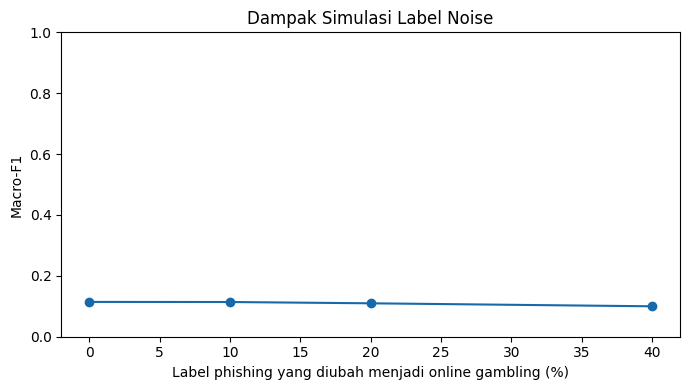

In [18]:
plt.figure(figsize=(7, 4))
plt.plot(
    noise_results["label_noise"] * 100,
    noise_results["macro_f1"],
    marker="o",
    color="#1769aa"
)

plt.ylim(0, 1)
plt.xlabel("Label phishing yang diubah menjadi online gambling (%)")
plt.ylabel("Macro-F1")
plt.title("Dampak Simulasi Label Noise")
plt.tight_layout()
plt.show()

Semakin banyak contoh phishing yang diberi label kategori lain, semakin sedikit pola phishing yang dapat dipelajari. Karena pemilihan baris tetap mengandung unsur acak, perubahan skor tidak harus mulus pada setiap percobaan. Ulangi simulasi dengan beberapa seed jika ingin memperkirakan rata-rata dampaknya.

Test label pada simulasi ini dianggap sebagai rujukan. Jika test label juga bermasalah, skor evaluasi ikut menjadi tidak dapat dipercaya.

## Chapter 8 — Memperbaiki label dengan prosedur yang aman

Perbaikan label sebaiknya mengikuti alur berikut:

1. **Tetapkan pedoman label.** Setiap kategori mempunyai definisi, contoh positif, contoh negatif, dan aturan untuk kasus ambigu.
2. **Pilih kandidat pemeriksaan.** Gunakan konflik data, sampling acak, dan model disagreement.
3. **Periksa bukti asli.** Jangan hanya melihat prediksi model.
4. **Gunakan reviewer kedua** untuk kasus yang sulit atau berdampak besar.
5. **Catat perubahan.** Simpan label lama, label baru, reviewer, waktu, dan alasan.
6. **Pisahkan versi data.** Hasil sebelum dan sesudah koreksi harus dapat direproduksi.
7. **Evaluasi ulang semua model** pada test set yang sudah diaudit.

Jika label hasil review sudah tersedia, koreksi dapat diterapkan berdasarkan `row_id`. Contoh berikut hanya menunjukkan bentuk prosesnya dan tidak mengubah data sekarang.

In [19]:
# Contoh format hasil review manual
review_result_example = pd.DataFrame({
    "row_id": [12, 45],
    "reviewed_label": ["phishing", "fakeshop"],
    "review_status": ["salah", "salah"],
    "review_note": ["sesuai bukti tangkapan layar", "sesuai pedoman kategori"]
})

review_result_example

,row_id,reviewed_label,review_status,review_note
0,12,phishing,salah,sesuai bukti tangkapan layar
1,45,fakeshop,salah,sesuai pedoman kategori


In [20]:
# Contoh cara menerapkan hasil review yang sudah disetujui
idadx_corrected = idadx.copy()

approved_review = review_result_example[
    review_result_example["review_status"] == "salah"
]

label_update = approved_review.set_index("row_id")["reviewed_label"]

rows_to_update = idadx_corrected["row_id"].isin(label_update.index)
idadx_corrected.loc[rows_to_update, "category"] = (
    idadx_corrected.loc[rows_to_update, "row_id"].map(label_update)
)

print(f"Contoh label yang diperbarui: {rows_to_update.sum()}")

Contoh label yang diperbarui: 2


Pada pelaksanaan sebenarnya, hasil review contoh di atas harus diganti dengan hasil pemeriksaan yang sah. Jangan menggunakan angka atau label contoh sebagai koreksi data.

## Chapter 9 — Audit kualitas label

Model disagreement hanya salah satu cara menemukan masalah. Audit yang lebih baik menggabungkan beberapa sumber.

| Pemeriksaan | Pertanyaan yang dijawab |
|---|---|
| Distribusi kategori | Apakah ada kategori yang sangat kecil atau berubah tajam? |
| Duplikat | Apakah laporan yang sama dihitung berulang kali? |
| Konflik label | Apakah entitas yang sama memperoleh label berbeda? |
| Sampling acak | Berapa banyak masalah yang tidak dipilih model? |
| Model disagreement | Kasus mana yang tidak sesuai dengan pola yang dipelajari model? |
| Review dua anotator | Apakah manusia menerapkan pedoman secara konsisten? |
| Audit berdasarkan waktu | Apakah definisi atau pola label berubah antarperiode? |

Jika tersedia label dari dua reviewer, konsistensi dapat dihitung menggunakan Cohen's Kappa. Nilai agreement saja tidak cukup karena agreement tinggi masih mungkin terjadi pada data yang sangat tidak seimbang.

## Chapter 10 — Pitfall yang sering terjadi

1. **Menganggap model selalu benar.** Model dapat mempelajari bias dan artefak data.
2. **Mengaudit data dengan prediksi in-sample.** Gunakan prediksi out-of-fold.
3. **Menghapus semua disagreement.** Data sulit justru dapat menjadi contoh penting.
4. **Memeriksa hanya kategori besar.** Kategori kecil memiliki pengaruh yang sama pada Macro-F1.
5. **Menggunakan bukti terbaru untuk kejadian lama.** Isi domain dapat berubah.
6. **Mengoreksi test label setelah melihat prediksi tim tertentu.** Audit test set harus mengikuti prosedur yang sama dan tidak memihak.
7. **Tidak menyimpan riwayat perubahan.** Tanpa versi dan alasan, hasil sulit direproduksi.
8. **Membiarkan domain atau kampanye yang sama tersebar di beberapa fold.** Skor dapat terlihat lebih baik daripada kemampuan generalisasi sebenarnya.

### Kelebihan model-assisted label review

- membantu memprioritaskan ribuan laporan;
- dapat menemukan pola konflik yang sulit terlihat secara manual;
- dapat diulang setelah dataset diperbarui.

### Kekurangannya

- kualitas kandidat bergantung pada kualitas model;
- model cenderung mempertahankan bias label mayoritas;
- margin SVM bukan probabilitas;
- tetap membutuhkan waktu dan keahlian reviewer.

## Chapter 11 — Tahap lanjutan

Setelah alur dasar dipahami, pengembangan dapat dilakukan secara bertahap:

1. gunakan **cross-validation**;
2. prioritaskan review dengan kombinasi disagreement, margin, dan konflik metadata;
3. ambil sampel acak sebagai pembanding agar audit tidak hanya mengikuti bias model;
4. ukur agreement antar-anotator pada sampel yang sama;
5. gunakan confident learning atau estimasi matriks noise setelah baseline kuat;
6. lakukan active learning untuk memilih data yang paling informatif;
7. audit label berdasarkan periode untuk mendeteksi concept drift;
8. buat gold test set kecil yang diperiksa lebih ketat daripada training data.

Metode yang lebih canggih tetap tidak menggantikan definisi kategori dan bukti anotasi yang jelas.

## Penutup

Pesan utama modul ini:

> **Model disagreement adalah undangan untuk memeriksa data, bukan izin untuk mengganti label secara otomatis.**

Alur kerja yang disarankan:

1. rapikan format label;
2. periksa duplikat dan konflik;
3. buat prediksi out-of-fold;
4. urutkan kandidat review;
5. periksa bukti secara manual;
6. simpan riwayat koreksi;
7. latih dan evaluasi ulang model menggunakan Macro-F1.

Macro-F1 tetap digunakan agar perbaikan pada kategori besar tidak menutupi kegagalan pada kategori kecil.